In [ ]:
import pandas as pd

df = pd.read_csv("../data/GlobalWeatherRepository.csv")

df.columns = df.columns.str.lower().str.strip()
df['last_updated'] = pd.to_datetime(df['last_updated'])
df.rename(columns={'temperature_celsius': 'temperature'}, inplace=True)

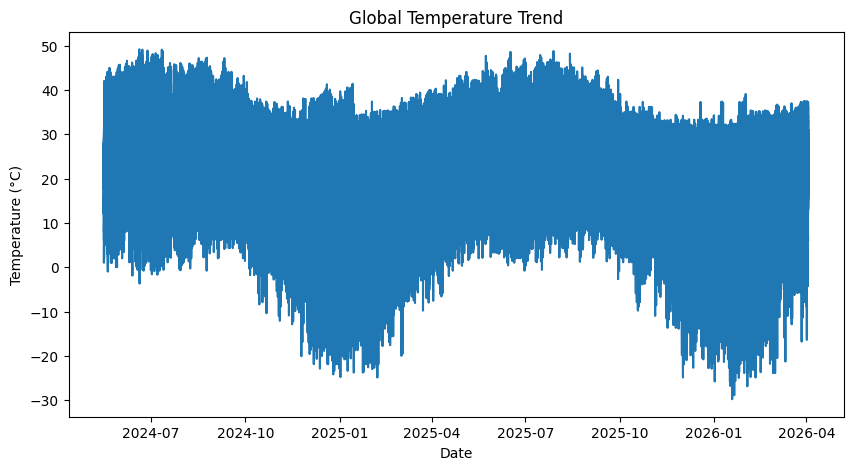

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['last_updated'], df['temperature'])
plt.title("Global Temperature Trend")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()

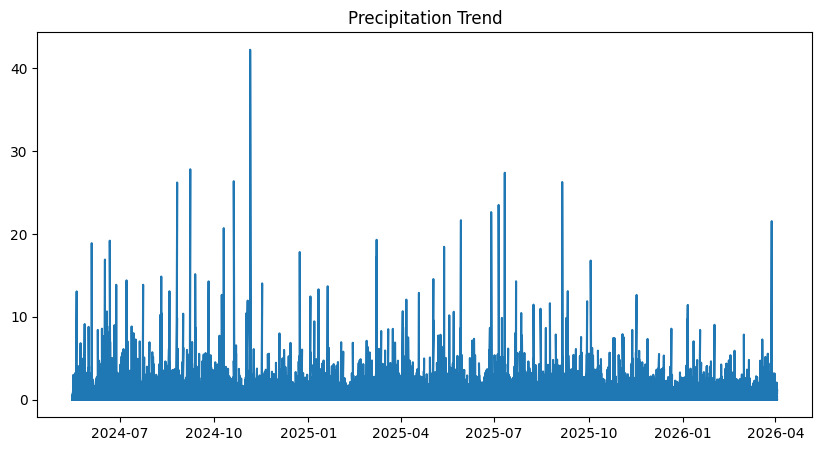

In [10]:
plt.figure(figsize=(10,5))
plt.plot(df['last_updated'], df['precip_mm'])
plt.title("Precipitation Trend")
plt.show()

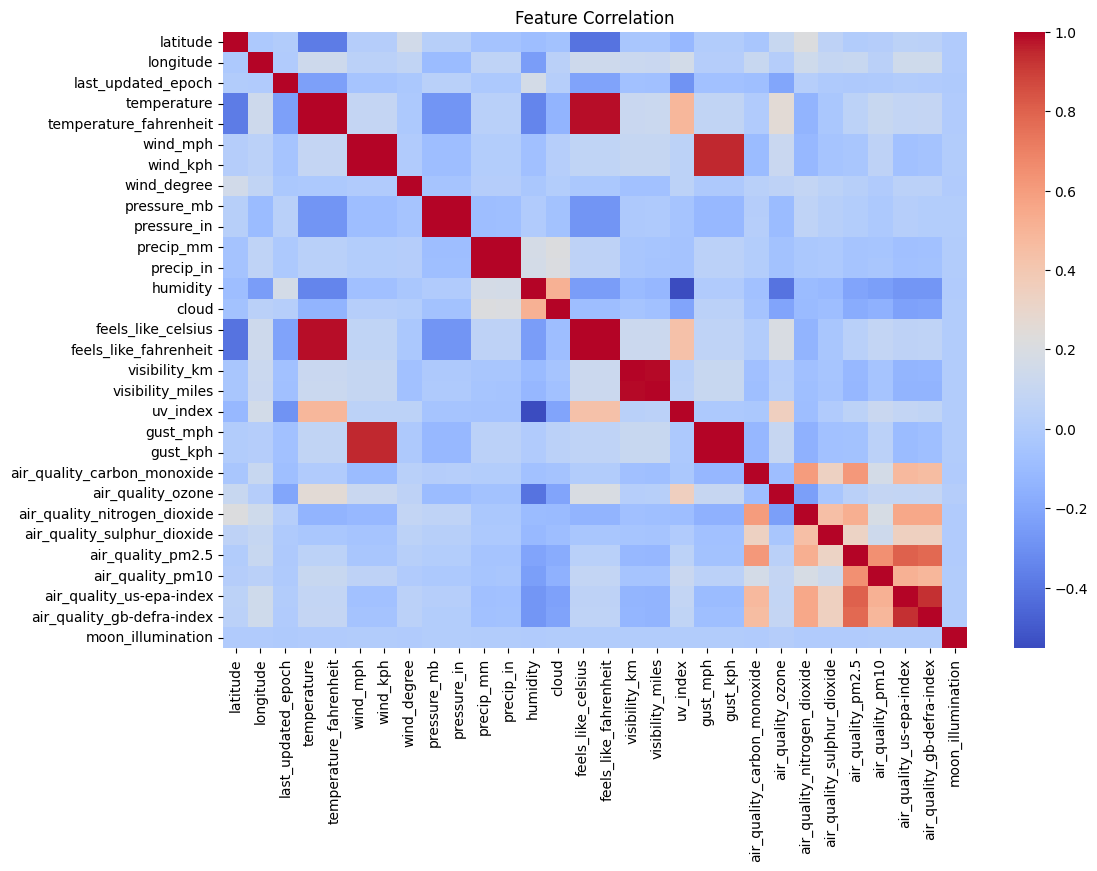

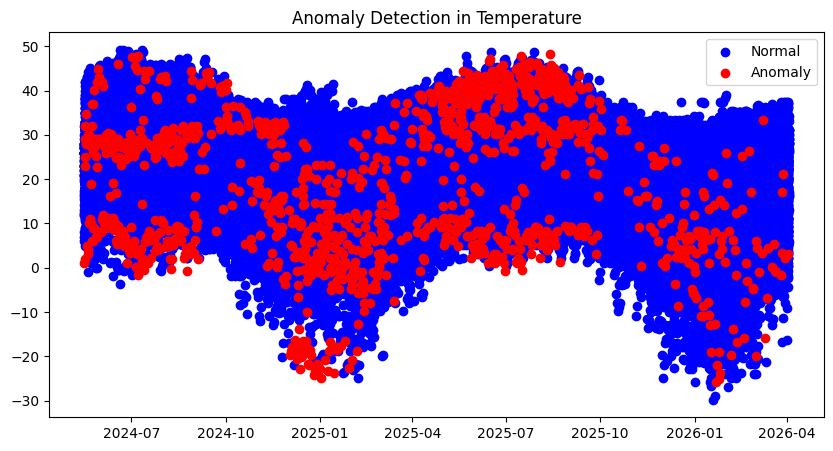

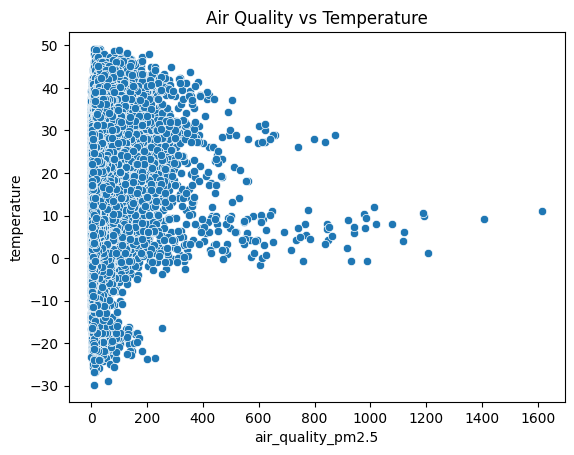

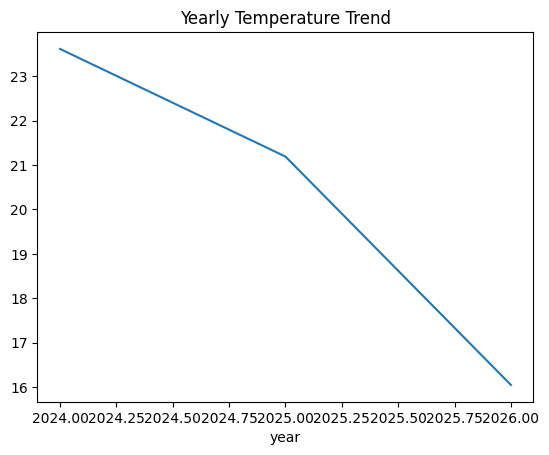

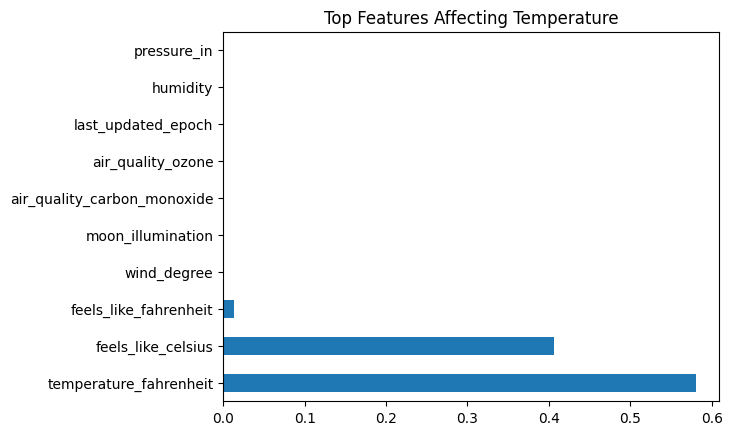

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest, RandomForestRegressor

# Ensure columns are clean
df.columns = df.columns.str.lower().str.strip()

numeric_df = df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

model = IsolationForest(contamination=0.01, random_state=42)
df['anomaly'] = model.fit_predict(numeric_df)

normal = df[df['anomaly'] == 1]
anomaly = df[df['anomaly'] == -1]

plt.figure(figsize=(10,5))
plt.scatter(normal['last_updated'], normal['temperature'], color='blue', label='Normal')
plt.scatter(anomaly['last_updated'], anomaly['temperature'], color='red', label='Anomaly')
plt.legend()
plt.title("Anomaly Detection in Temperature")
plt.show()

sns.scatterplot(x='air_quality_pm2.5', y='temperature', data=df)
plt.title("Air Quality vs Temperature")
plt.show()
df['year'] = df['last_updated'].dt.year
yearly_avg = df.groupby('year')['temperature'].mean()

yearly_avg.plot(title="Yearly Temperature Trend")
plt.show()

X = numeric_df.drop(columns=['temperature'])
y = df['temperature']

rf = RandomForestRegressor()
rf.fit(X, y)

feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh')

plt.title("Top Features Affecting Temperature")
plt.show()

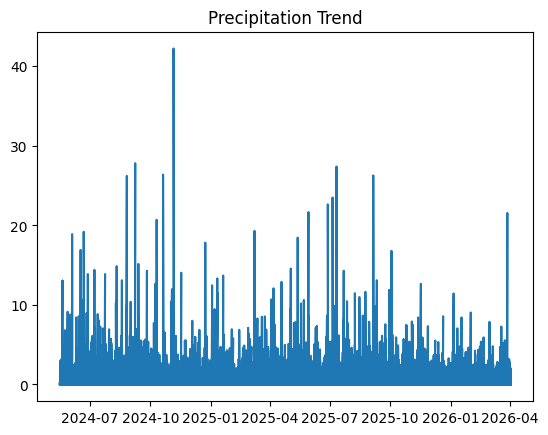

In [21]:
plt.plot(df['last_updated'], df['precip_mm'])
plt.title("Precipitation Trend")
plt.show()